Please upload one or multiple wall surface images...


Saving crack image 3.jpg to crack image 3 (1).jpg
Saving crack image 2.jpg to crack image 2 (1).jpg
Saving crack image 1.jpg to crack image 1 (1).jpg


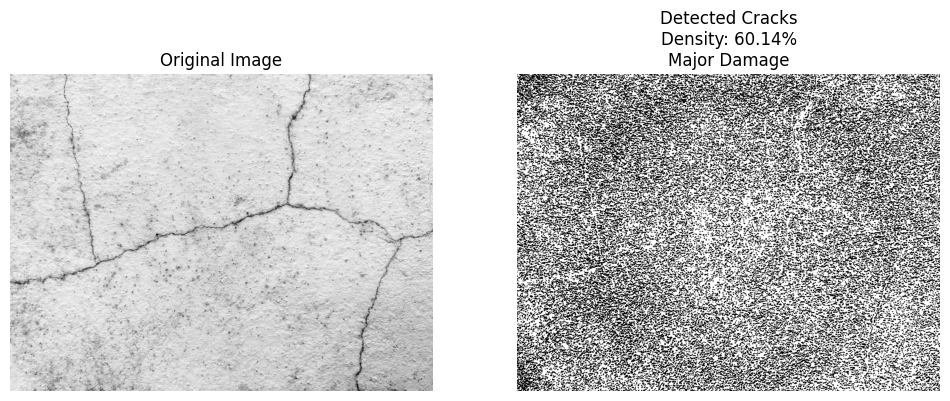

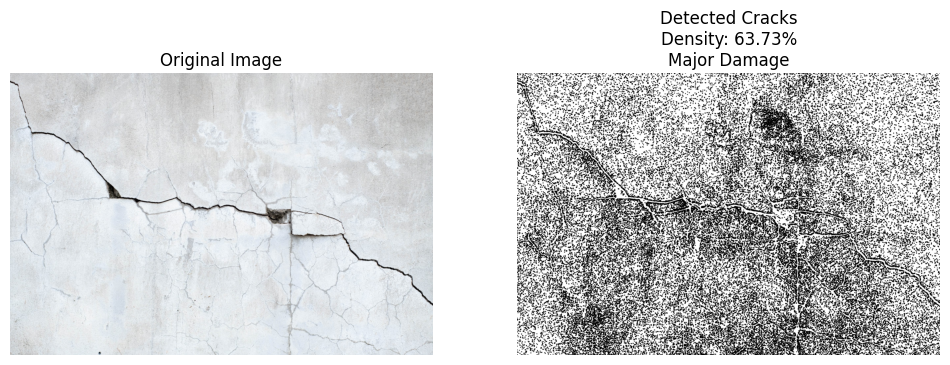

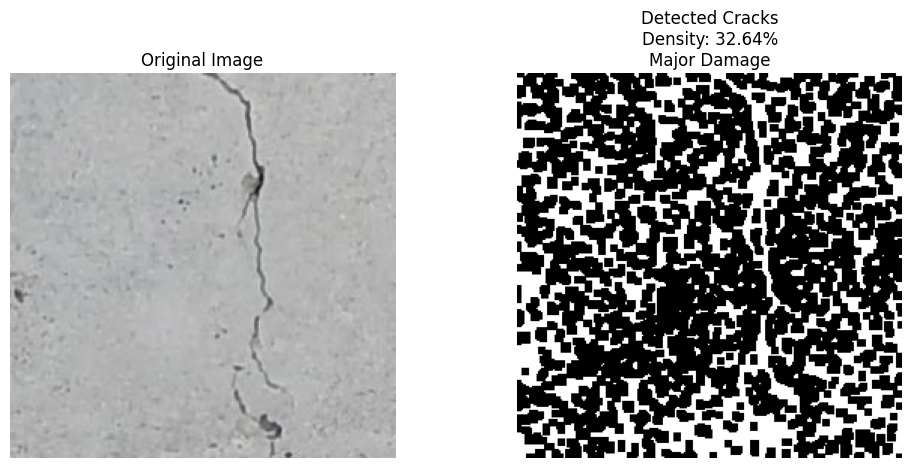


STRUCTURAL DAMAGE REPORT

Image: crack image 3 (1).jpg
Crack Density (%): 60.14
Damage Level: Major Damage

Image: crack image 2 (1).jpg
Crack Density (%): 63.73
Damage Level: Major Damage

Image: crack image 1 (1).jpg
Crack Density (%): 32.64
Damage Level: Major Damage


In [8]:
# ============================================================
# MUNICIPAL WALL CRACK DETECTION (UPLOAD YOUR OWN IMAGES)
# OpenCV Segmentation + Density + Classification
# Google Colab Ready
# ============================================================

# Install required libraries (if needed in Colab)
!pip -q install opencv-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# STEP 1: Upload Images (Colab Upload Option)
# ============================================================

from google.colab import files

print("Please upload one or multiple wall surface images...")
uploaded = files.upload()

image_paths = list(uploaded.keys())

# ============================================================
# STEP 2: Crack Detection Function
# ============================================================

def detect_cracks(image_path):
    img = cv2.imread(image_path)
    original = img.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise reduction
    blurred = cv2.GaussianBlur(gray, (5,5), 0)

    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    # Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Crack density calculation
    crack_pixels = np.sum(cleaned == 255)
    total_pixels = cleaned.size
    crack_density = (crack_pixels / total_pixels) * 100

    return original, cleaned, crack_density


# ============================================================
# STEP 3: Damage Classification
# ============================================================

def classify_damage(density):
    if density < 1:
        return "No Damage"
    elif 1 <= density < 3:
        return "Minor Damage"
    else:
        return "Major Damage"


# ============================================================
# STEP 4: Process Uploaded Images
# ============================================================

results = []

for path in image_paths:
    original, mask, density = detect_cracks(path)
    severity = classify_damage(density)

    results.append({
        "Image": path,
        "Crack Density (%)": round(density, 2),
        "Damage Level": severity
    })

    # Display results
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Detected Cracks\nDensity: {density:.2f}%\n{severity}")
    plt.axis("off")

    plt.show()


# ============================================================
# STEP 5: Summary Report
# ============================================================

print("\n========================================")
print("STRUCTURAL DAMAGE REPORT")
print("========================================")

for r in results:
    print(f"\nImage: {r['Image']}")
    print(f"Crack Density (%): {r['Crack Density (%)']}")
    print(f"Damage Level: {r['Damage Level']}")

# ============================================================
# END
# ============================================================